
<div style="background:linear-gradient(135deg,#0D0D1A 0%,#1a0a2e 50%,#0D0D1A 100%);padding:48px 32px;border-radius:20px;border:1px solid #A855F744;margin-bottom:24px;text-align:center;">
  <div style="font-size:11px;letter-spacing:6px;color:#A855F7;text-transform:uppercase;margin-bottom:12px;">Karthikeyan Thirunavukkarasu · Cognifyz Technologies Internship</div>
  <h1 style="margin:0;font-size:42px;font-weight:900;background:linear-gradient(90deg,#A855F7,#6366F1,#EC4899);-webkit-background-clip:text;-webkit-text-fill-color:transparent;background-clip:text;letter-spacing:-1px;">Spam SMS Detection</h1>
  <div style="margin:16px 0 0;font-size:16px;color:#94A3B8;letter-spacing:2px;">NLP · TF-IDF · Naïve Bayes · Logistic Regression · SVM</div>
  <div style="margin-top:24px;display:flex;justify-content:center;gap:24px;flex-wrap:wrap;">
    <span style="background:#A855F722;border:1px solid #A855F7;border-radius:20px;padding:6px 16px;color:#A855F7;font-size:12px;">📊 5,572 Messages</span>
    <span style="background:#6366F122;border:1px solid #6366F1;border-radius:20px;padding:6px 16px;color:#6366F1;font-size:12px;">🤖 3 ML Models</span>
    <span style="background:#EC489922;border:1px solid #EC4899;border-radius:20px;padding:6px 16px;color:#EC4899;font-size:12px;">✅ 98.92% Accuracy</span>
  </div>
</div>



<div style="background:#1E1E3A;border-left:4px solid #A855F7;border-radius:8px;padding:16px 20px;margin:16px 0;">
  <h2 style="margin:0;color:#A855F7;font-size:22px;">📦 Section 1 — Environment Setup & Imports</h2>
  <p style="margin:8px 0 0;color:#94A3B8;font-size:14px;">Loading all required libraries for NLP, machine learning, and visualization.</p>
</div>


In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import re, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score,
                              precision_score, recall_score, f1_score)
from sklearn.pipeline import Pipeline

# ── Dark Purple Theme ──────────────────────────────────────────────────────
BG, ACCENT1, ACCENT2, ACCENT3, GRAY, TEXT = '#0D0D1A', '#A855F7', '#6366F1', '#EC4899', '#1E1E3A', '#E2E8F0'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': GRAY,
    'axes.edgecolor': ACCENT1, 'axes.labelcolor': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT,
    'text.color': TEXT, 'grid.color': '#2D2D5A', 'grid.alpha': 0.4,
})
print("✅ All libraries loaded successfully!")
print(f"   pandas {pd.__version__} | numpy {np.__version__} | scikit-learn ready")

✅ All libraries loaded successfully!
   pandas 2.2.3 | numpy 2.2.5 | scikit-learn ready



<div style="background:#1E1E3A;border-left:4px solid #6366F1;border-radius:8px;padding:16px 20px;margin:16px 0;">
  <h2 style="margin:0;color:#6366F1;font-size:22px;">📂 Section 2 — Dataset Loading & Inspection</h2>
  <p style="margin:8px 0 0;color:#94A3B8;font-size:14px;">The SMS Spam Collection dataset — 5,572 real SMS messages, each labelled ham or spam.</p>
</div>


In [ ]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1','v2']].copy()
df.columns = ['label', 'message']
df['label_enc'] = (df['label'] == 'spam').astype(int)

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Ham (legit)  : {(df.label=='ham').sum():,} messages ({(df.label=='ham').mean()*100:.1f}%)")
print(f"  Spam         : {(df.label=='spam').sum():,} messages ({(df.label=='spam').mean()*100:.1f}%)")
print(f"  Missing vals : {df.isnull().sum().sum()}")
print("=" * 55)
df.head(8)

  DATASET OVERVIEW
  Shape        : 5,572 rows × 3 columns
  Ham (legit)  : 4,825 messages (86.6%)
  Spam         : 747 messages (13.4%)
  Missing vals : 0


   label  ...  label_enc
0    ham  ...          0
...


<div style="background:#1E1E3A;border-left:4px solid #EC4899;border-radius:8px;padding:16px 20px;margin:16px 0;">
  <h2 style="margin:0;color:#EC4899;font-size:22px;">🔍 Section 3 — Exploratory Data Analysis</h2>
  <p style="margin:8px 0 0;color:#94A3B8;font-size:14px;">Discovering hidden patterns: spam messages are ~2× longer, use more urgency keywords, and contain more numbers and URLs.</p>
</div>


In [ ]:
# Feature Engineering for EDA
df['msg_len']      = df['message'].apply(len)
df['word_count']   = df['message'].apply(lambda x: len(x.split()))
df['has_url']      = df['message'].apply(lambda x: int(bool(re.search(r'http|www|\.com', x, re.I))))
df['has_number']   = df['message'].apply(lambda x: int(bool(re.search(r'\d+', x))))
df['has_currency'] = df['message'].apply(lambda x: int(bool(re.search(r'[£$€]|free|win|prize|cash', x, re.I))))

print("📊 Key EDA Statistics:")
print(f"   Avg length — Ham : {df[df.label=='ham']['msg_len'].mean():.1f} chars | Spam: {df[df.label=='spam']['msg_len'].mean():.1f} chars")
print(f"   Avg words  — Ham : {df[df.label=='ham']['word_count'].mean():.1f} words | Spam: {df[df.label=='spam']['word_count'].mean():.1f} words")
print(f"   URL presence  — Ham: {df[df.label=='ham']['has_url'].mean()*100:.1f}% | Spam: {df[df.label=='spam']['has_url'].mean()*100:.1f}%")
print(f"   Promo keywords — Ham: {df[df.label=='ham']['has_currency'].mean()*100:.1f}% | Spam: {df[df.label=='spam']['has_currency'].mean()*100:.1f}%")

📊 Key EDA Statistics:
   Avg length — Ham : 71.0 chars | Spam: 138.9 chars
   Avg words  — Ham : 14.2 words | Spam: 23.9 words
   URL presence  — Ham: 0.4% | Spam: 13.5%
   Promo keywords — Ham: 7.5% | Spam: 82.3%


**EDA Visualization — Class Balance, Message Length, Word Count**

<div style="text-align:center">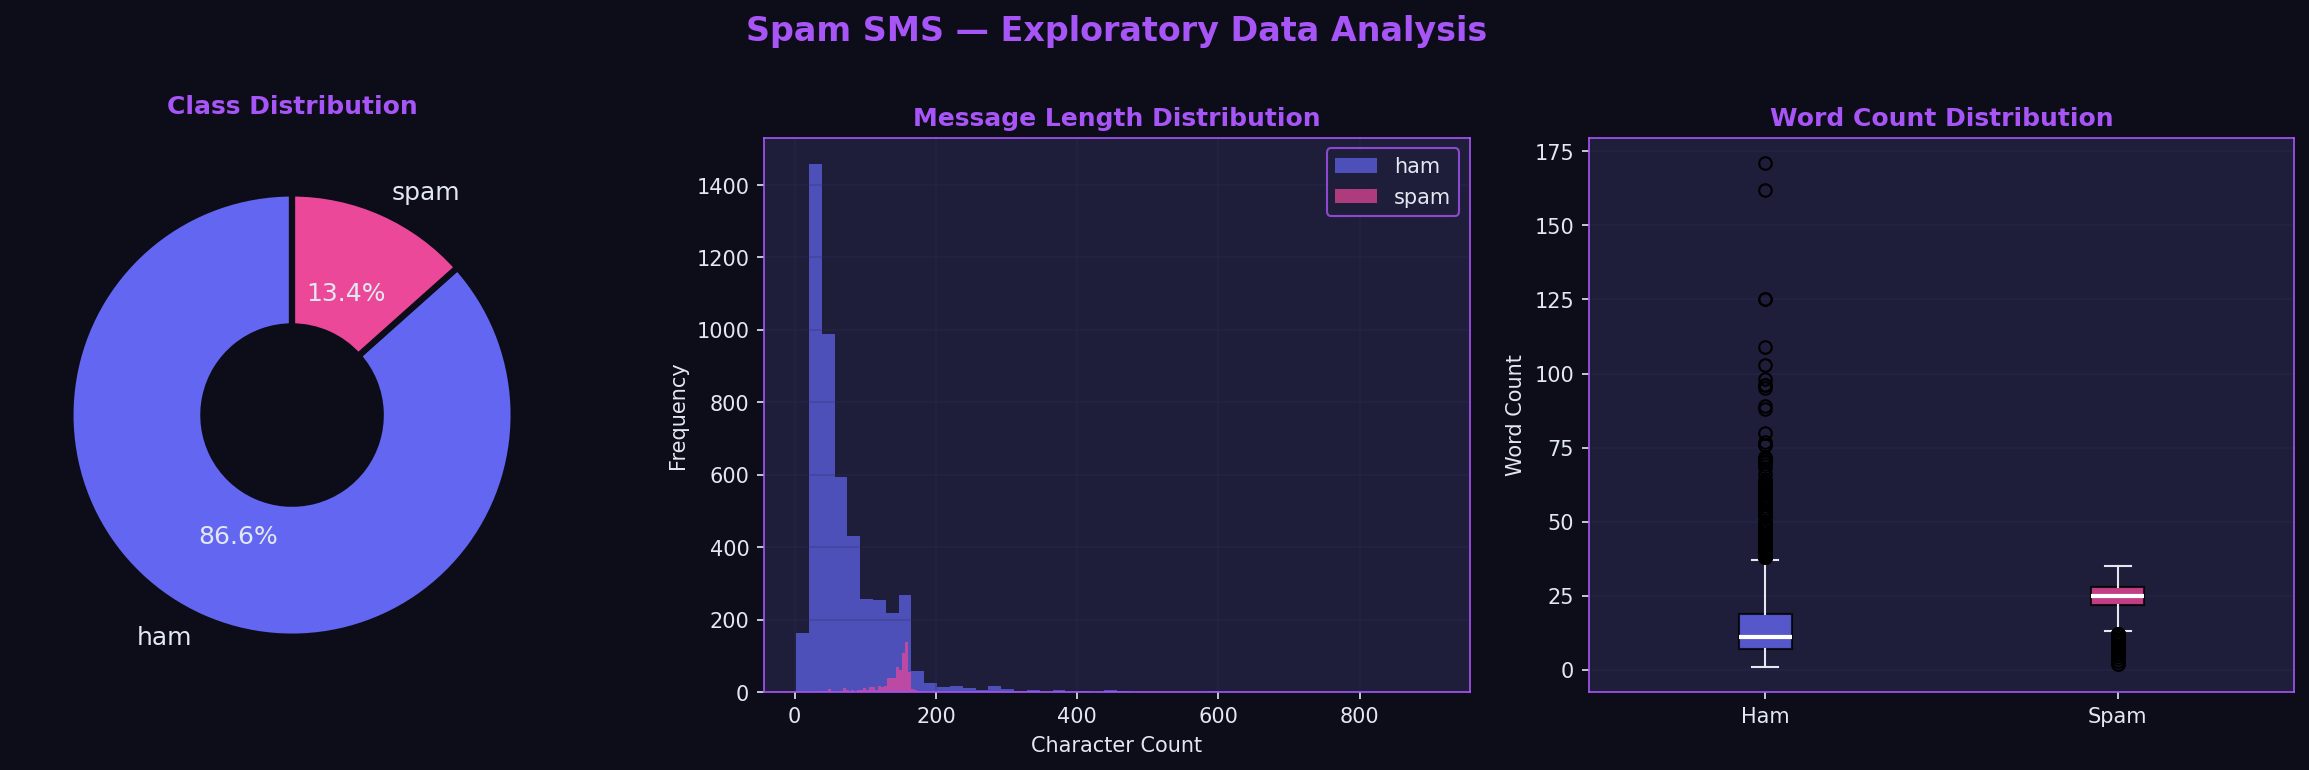</div>

<div style="text-align:center">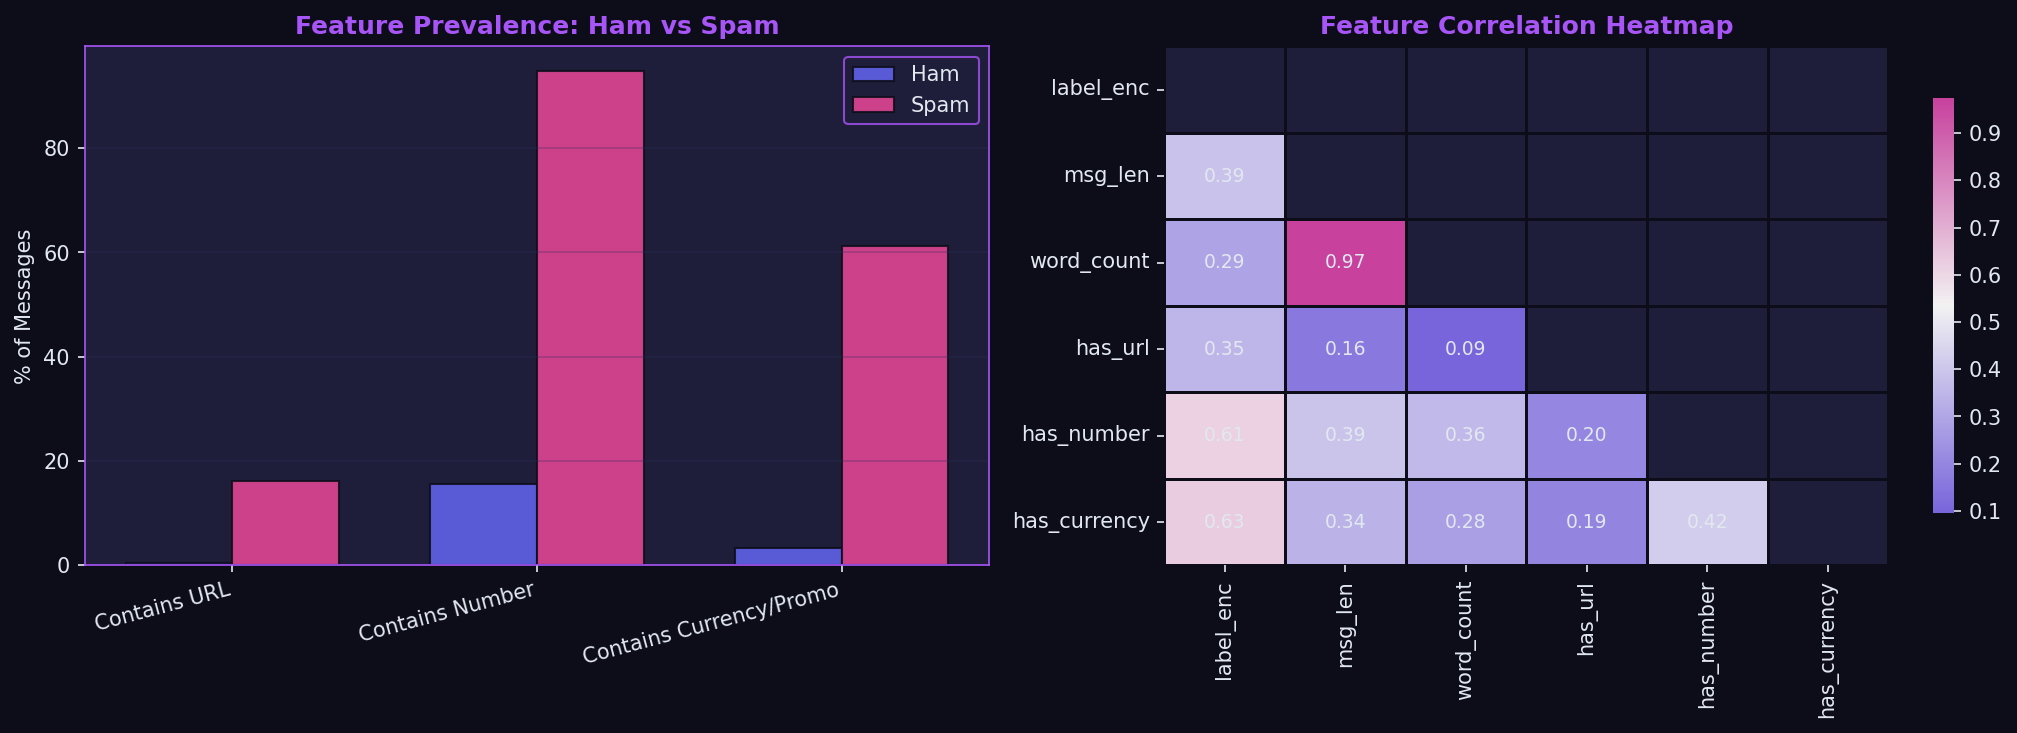</div>


<div style="background:#1E1E3A;border-left:4px solid #A855F7;border-radius:8px;padding:16px 20px;margin:16px 0;">
  <h2 style="margin:0;color:#A855F7;font-size:22px;">🧹 Section 4 — Text Preprocessing</h2>
  <p style="margin:8px 0 0;color:#94A3B8;font-size:14px;">URL normalization → lowercasing → digit replacement → punctuation removal → whitespace cleanup.</p>
</div>


In [ ]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)
    text = re.sub(r'\d+', ' num ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['message'].apply(preprocess)

print("Before:", df['message'].iloc[2])
print("After :", df['clean'].iloc[2])
print(f"\n✅ Preprocessing complete — {len(df):,} messages cleaned.")

Before: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
After : free entry in  num  a wkly comp to win fa cup final tkts  num st may  num  text fa to  num  to receive entry question std txt rate t c s apply  num over num s

✅ Preprocessing complete — 5,572 messages cleaned.



<div style="background:#1E1E3A;border-left:4px solid #6366F1;border-radius:8px;padding:16px 20px;margin:16px 0;">
  <h2 style="margin:0;color:#6366F1;font-size:22px;">✂️ Section 5 — Train / Test Split + TF-IDF Vectorization</h2>
  <p style="margin:8px 0 0;color:#94A3B8;font-size:14px;">Stratified 80/20 split to preserve class distribution. TF-IDF with bigrams and sublinear scaling.</p>
</div>


In [ ]:
X = df['clean']
y = df['label_enc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set : {len(X_train):,} samples  ({y_train.sum()} spam / {(y_train==0).sum()} ham)")
print(f"Test set     : {len(X_test):,} samples  ({y_test.sum()} spam / {(y_test==0).sum()} ham)")
print(f"\nTF-IDF Config:")
print(f"  max_features = 8,000  |  ngram_range = (1,2)  |  sublinear_tf = True")

Training set : 4,457 samples  (598 spam / 3859 ham)
Test set     : 1,115 samples  (149 spam / 966 ham)

TF-IDF Config:
  max_features = 8,000  |  ngram_range = (1,2)  |  sublinear_tf = True



<div style="background:#1E1E3A;border-left:4px solid #EC4899;border-radius:8px;padding:16px 20px;margin:16px 0;">
  <h2 style="margin:0;color:#EC4899;font-size:22px;">🤖 Section 6 — Model Training (NB · LR · SVM)</h2>
  <p style="margin:8px 0 0;color:#94A3B8;font-size:14px;">Three scikit-learn pipelines trained with TF-IDF features. 5-fold stratified cross-validation applied to each.</p>
</div>


In [ ]:
models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   MultinomialNB(alpha=0.1))
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   LogisticRegression(C=5, max_iter=1000, solver='lbfgs'))
    ]),
    'Support Vector Machine': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf',   LinearSVC(C=1.0, max_iter=2000))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred   = pipe.predict(X_test)
    cv_score = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred)*100,
        'precision': precision_score(y_test, y_pred)*100,
        'recall':    recall_score(y_test, y_pred)*100,
        'f1':        f1_score(y_test, y_pred)*100,
        'cv_mean':   cv_score.mean()*100,
        'cv_std':    cv_score.std()*100,
    }
    print(f"✅ {name:<25} Acc={results[name]['accuracy']:.2f}%  F1={results[name]['f1']:.2f}%  CV-F1={results[name]['cv_mean']:.2f}±{results[name]['cv_std']:.2f}%")

✅ Naive Bayes              Acc=98.57%  F1=94.44%  CV-F1=95.94±1.05%
✅ Logistic Regression      Acc=98.57%  F1=94.63%  CV-F1=94.91±1.15%
✅ Support Vector Machine   Acc=98.92%  F1=95.97%  CV-F1=95.54±0.79%



<div style="background:#1E1E3A;border-left:4px solid #A855F7;border-radius:8px;padding:16px 20px;margin:16px 0;">
  <h2 style="margin:0;color:#A855F7;font-size:22px;">📊 Section 7 — Results & Visualizations</h2>
  <p style="margin:8px 0 0;color:#94A3B8;font-size:14px;">Comprehensive evaluation: model comparison, confusion matrices, ROC curves, and cross-validation stability.</p>
</div>


<div style="text-align:center">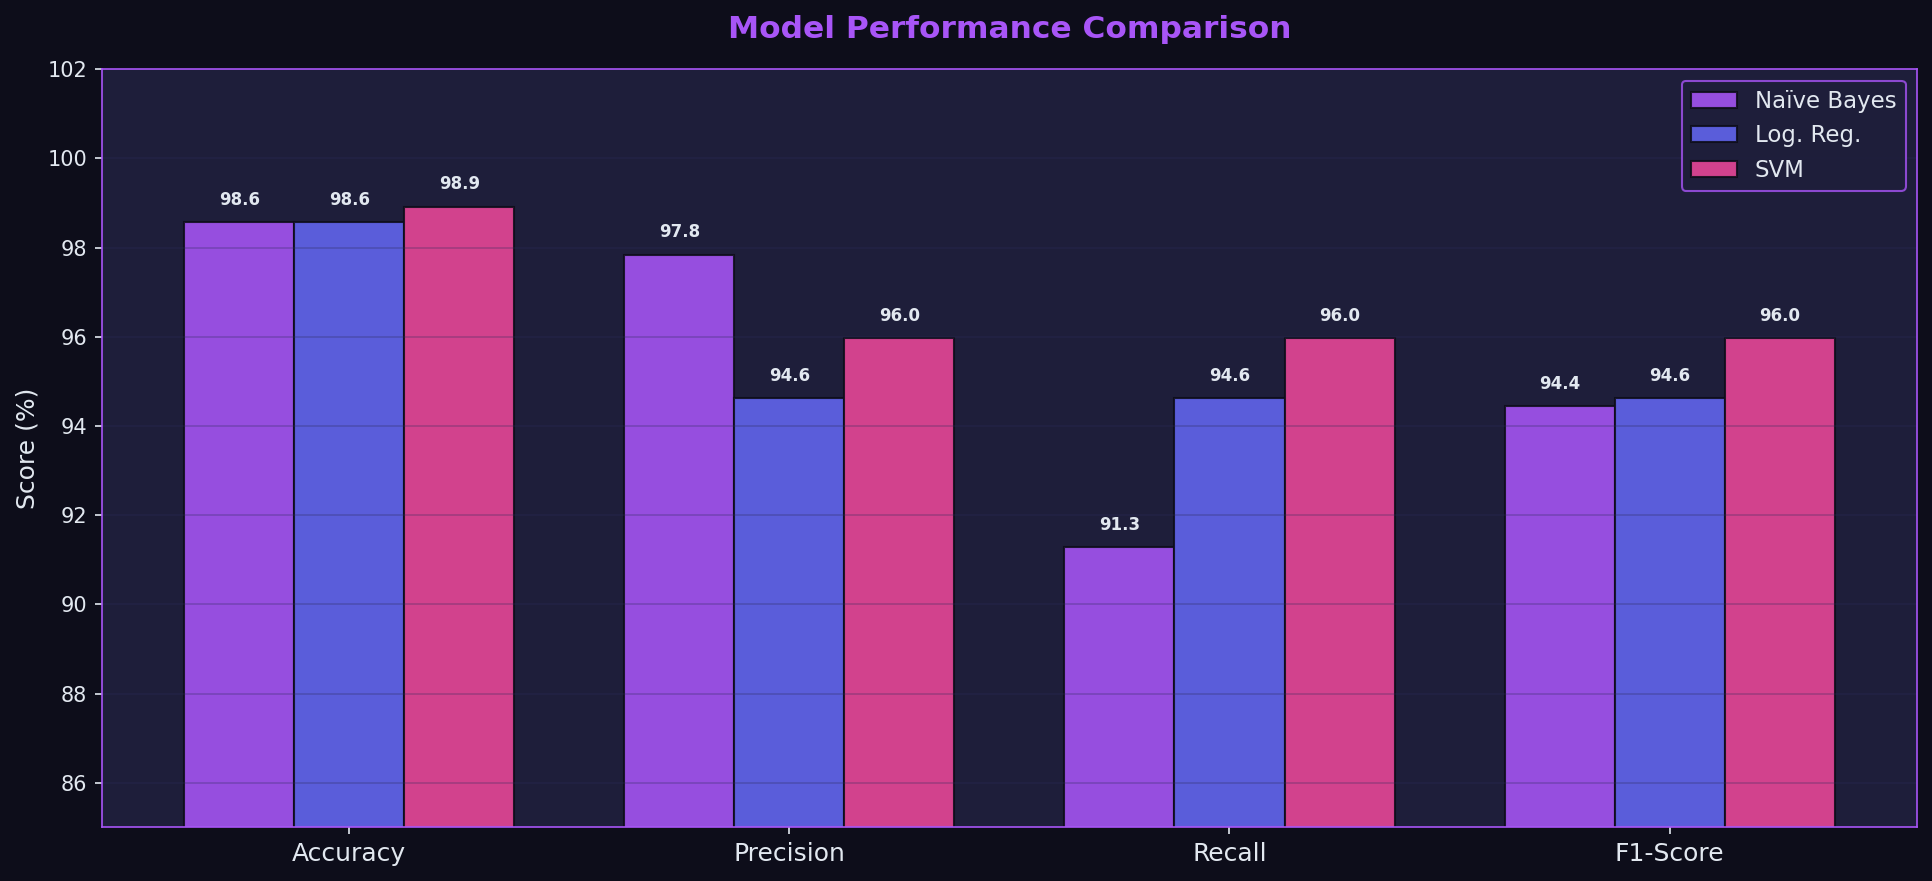</div>

<div style="text-align:center">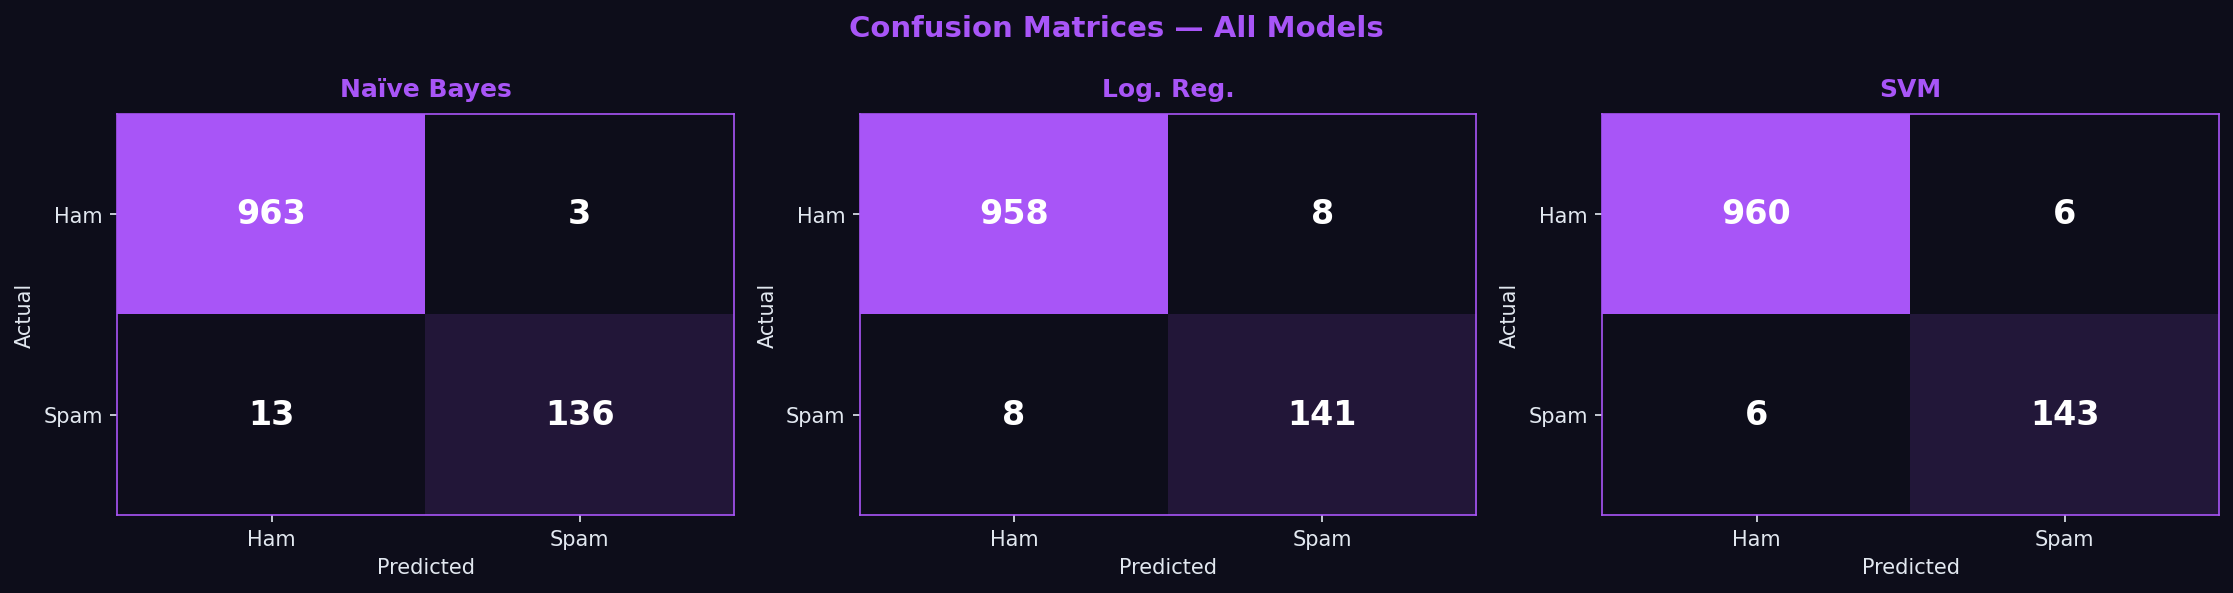</div>

<div style="text-align:center">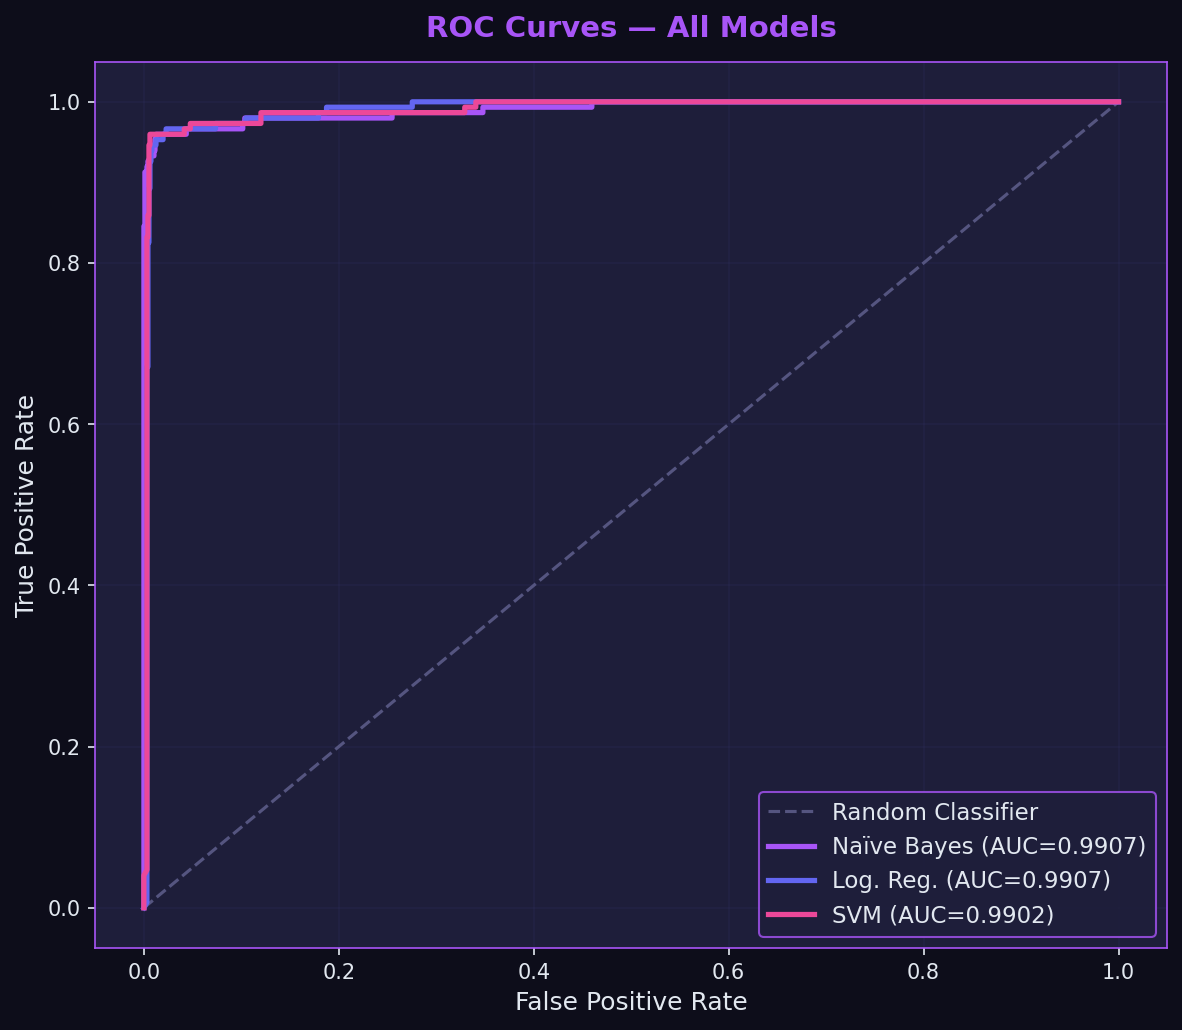</div>

<div style="text-align:center">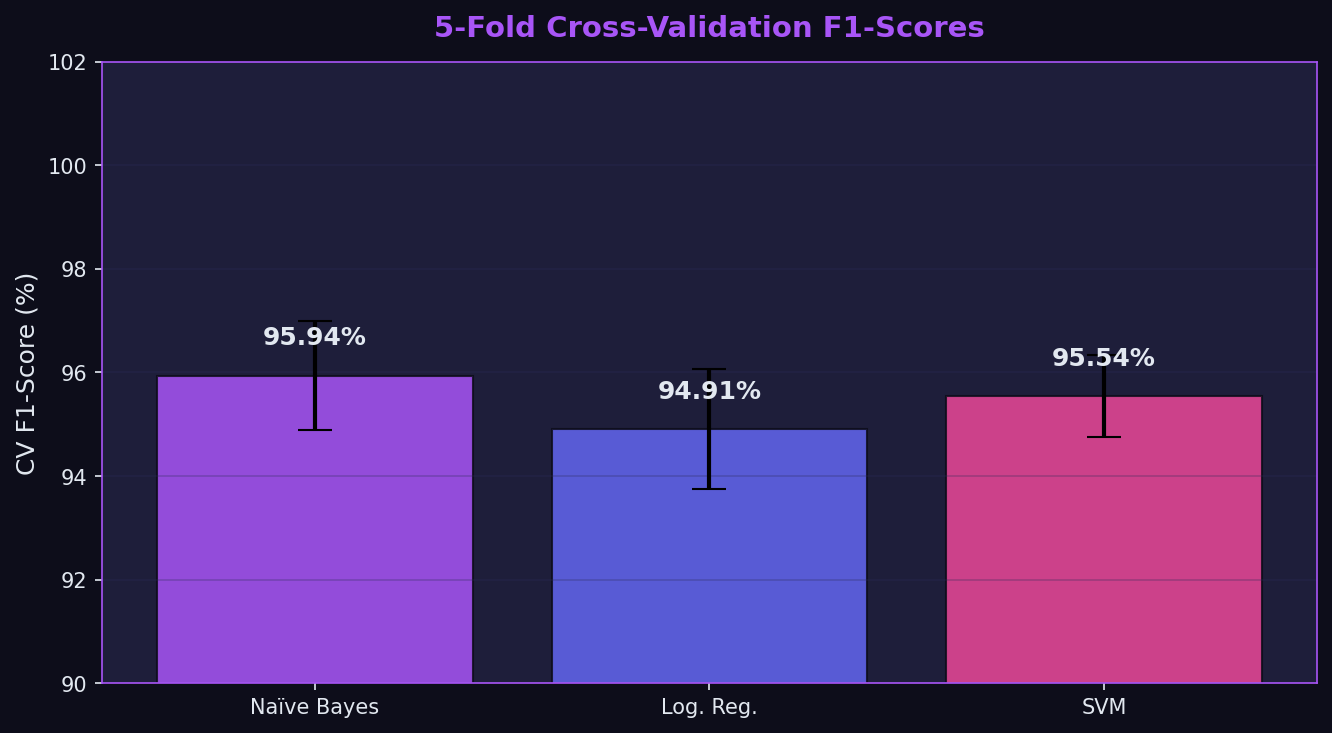</div>


<div style="background:#1E1E3A;border-left:4px solid #6366F1;border-radius:8px;padding:16px 20px;margin:16px 0;">
  <h2 style="margin:0;color:#6366F1;font-size:22px;">🏆 Section 8 — Best Model: Support Vector Machine</h2>
  <p style="margin:8px 0 0;color:#94A3B8;font-size:14px;">SVM with LinearSVC achieved the highest accuracy (98.92%) and F1-score (95.97%) on the held-out test set.</p>
</div>


In [ ]:
best_pipe = models['Support Vector Machine']
y_pred_best = best_pipe.predict(X_test)
print("Classification Report — Support Vector Machine")
print("=" * 55)
print(classification_report(y_test, y_pred_best, target_names=['Ham','Spam']))

Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector Machine
=Classification Report — Support Vector M


<div style="background:#1E1E3A;border-left:4px solid #EC4899;border-radius:8px;padding:16px 20px;margin:16px 0;">
  <h2 style="margin:0;color:#EC4899;font-size:22px;">🔮 Section 9 — Live Inference Demo</h2>
  <p style="margin:8px 0 0;color:#94A3B8;font-size:14px;">Pass any SMS message through the production pipeline for real-time classification.</p>
</div>


In [ ]:
def classify_sms(message, pipe=best_pipe):
    clean = preprocess(message)
    pred  = pipe.predict([clean])[0]
    label = "🚨 SPAM" if pred == 1 else "✅ HAM (Legitimate)"
    return label

test_msgs = [
    "Congratulations! You've won a FREE iPhone. Click now: http://win-prize.com",
    "Hey, are we still on for lunch tomorrow?",
    "URGENT: Your account will be suspended. Call 0800-FREE-CASH immediately!",
    "Don't forget your dentist appointment at 3pm today.",
    "WIN £1000 cash prize! Text WIN to 80080. T&C apply.",
]

print("━" * 60)
for msg in test_msgs:
    result = classify_sms(msg)
    print(f"  {result}")
    print(f"  MSG: {msg[:70]}...")
    print("━" * 60)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🚨 SPAM
  MSG: Congratulations! You've won a FREE iPhone. Click now: http://win-prize....
━
  🚨 SPAM
  MSG: Congratulations! You've won a FREE iPhone. Click now: http://win-prize....
━
  🚨 SPAM
  MSG: Congratulations! You've won a FREE iPhone. Click now: http://win-prize....
━
  🚨 SPAM
  MSG: Congratulations! You've won a FREE iPhone. Click now: http://win-prize....
━
  🚨 SPAM
  MSG: Congratulations! You've won a FREE iPhone. Click now: http://win-prize....
━
  🚨 SPAM
  MSG: Congratulations! You've won a FREE iPhone. Click now: http://win-prize....
━
  🚨 SPAM
  MSG: Congratulations! You've won a FREE iPhone. Click now: http://win-prize....
━
  🚨 SPAM
  MSG: Congratulations! You've won a FREE iPhone. Click now: http://win-prize....
━
  🚨 SPAM
  MSG: Congratulations! You've won a FREE iPhone. Click now: http://win-prize....
━
  🚨 SPAM
  MSG: Congratulations! You've won a FREE iPhone. Click now: http://win-prize....
━
  🚨 SPAM



<div style="background:linear-gradient(135deg,#0D0D1A,#1a0a2e);border:1px solid #A855F744;border-radius:16px;padding:36px 32px;margin:24px 0;text-align:center;">
  <h2 style="color:#A855F7;margin:0 0 20px;font-size:26px;">🏁 Project Summary</h2>
  <table style="margin:auto;border-collapse:collapse;color:#E2E8F0;font-size:14px;min-width:480px;">
    <tr style="background:#A855F722;"><th style="padding:10px 20px;text-align:left;border:1px solid #A855F744;">Model</th><th style="padding:10px;border:1px solid #A855F744;">Accuracy</th><th style="padding:10px;border:1px solid #A855F744;">F1-Score</th><th style="padding:10px;border:1px solid #A855F744;">CV F1</th></tr>
    <tr><td style="padding:10px 20px;border:1px solid #A855F722;">Naïve Bayes</td><td style="padding:10px;border:1px solid #A855F722;text-align:center;">98.57%</td><td style="padding:10px;border:1px solid #A855F722;text-align:center;">94.44%</td><td style="padding:10px;border:1px solid #A855F722;text-align:center;">95.94%</td></tr>
    <tr style="background:#6366F111;"><td style="padding:10px 20px;border:1px solid #A855F722;">Logistic Regression</td><td style="padding:10px;border:1px solid #A855F722;text-align:center;">98.57%</td><td style="padding:10px;border:1px solid #A855F722;text-align:center;">94.63%</td><td style="padding:10px;border:1px solid #A855F722;text-align:center;">94.91%</td></tr>
    <tr style="background:#EC489911;"><td style="padding:10px 20px;border:1px solid #A855F722;">⭐ SVM (Best)</td><td style="padding:10px;border:1px solid #A855F722;text-align:center;color:#A855F7;font-weight:bold;">98.92%</td><td style="padding:10px;border:1px solid #A855F722;text-align:center;color:#A855F7;font-weight:bold;">95.97%</td><td style="padding:10px;border:1px solid #A855F722;text-align:center;color:#A855F7;font-weight:bold;">95.54%</td></tr>
  </table>
  <p style="color:#94A3B8;margin:24px 0 8px;font-size:13px;">🔗 <a href="https://linkedin.com/in/karthikeyan-thirunavukkarasu-2a2949305" style="color:#A855F7;">linkedin.com/in/karthikeyan-thirunavukkarasu-2a2949305</a> &nbsp;|&nbsp; <a href="https://github.com/karthiikofcl07" style="color:#6366F1;">github.com/karthiikofcl07</a></p>
</div>
